In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
#Loading the dataset
df = pd.read_csv("../Data/Raw/fake reviews dataset.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [9]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [10]:
print(df.duplicated().sum())

12


In [11]:
print(df.describe())

             rating
count  40432.000000
mean       4.256579
std        1.144354
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000


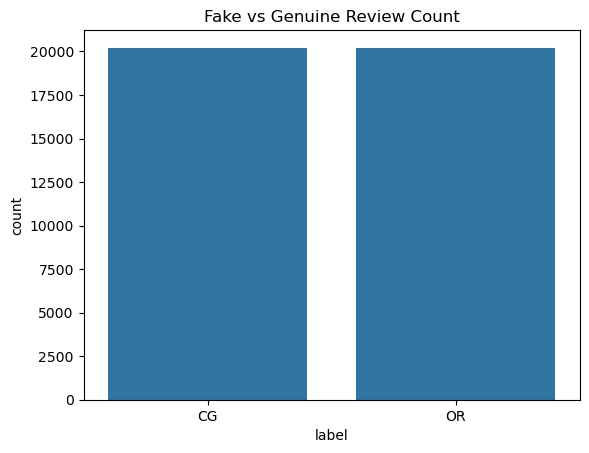

In [12]:
sns.countplot(x='label', data=df)
plt.title('Fake vs Genuine Review Count')
plt.show()

In [5]:
print(df['label'].value_counts())  # CG vs OR

label
CG    20216
OR    20216
Name: count, dtype: int64


Here the CG and OR both are in equal amount so the dataset in balanced 

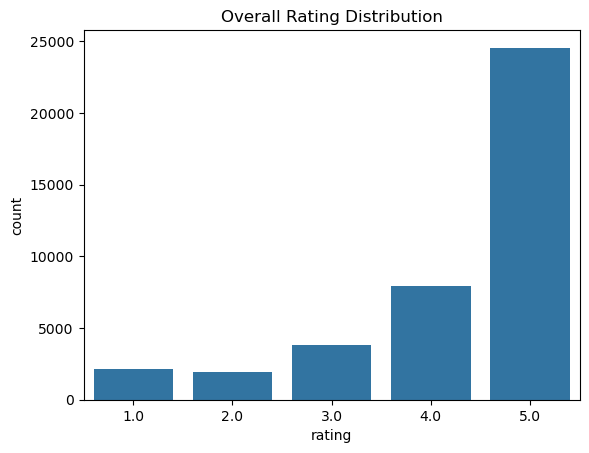

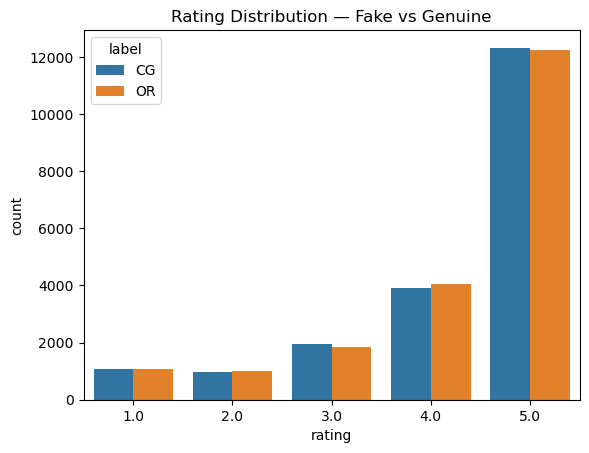

In [24]:
# Overall rating distribution
sns.countplot(x='rating', data=df)
plt.title('Overall Rating Distribution')
plt.show()

# Rating distribution split by fake vs genuine
sns.countplot(x='rating', hue='label', data=df)
plt.title('Rating Distribution — Fake vs Genuine')
plt.show()

KEY INSIGHT: Do fake reviews cluster at 5 stars? This tells
whether 'is_extreme_rating' will be a useful feature

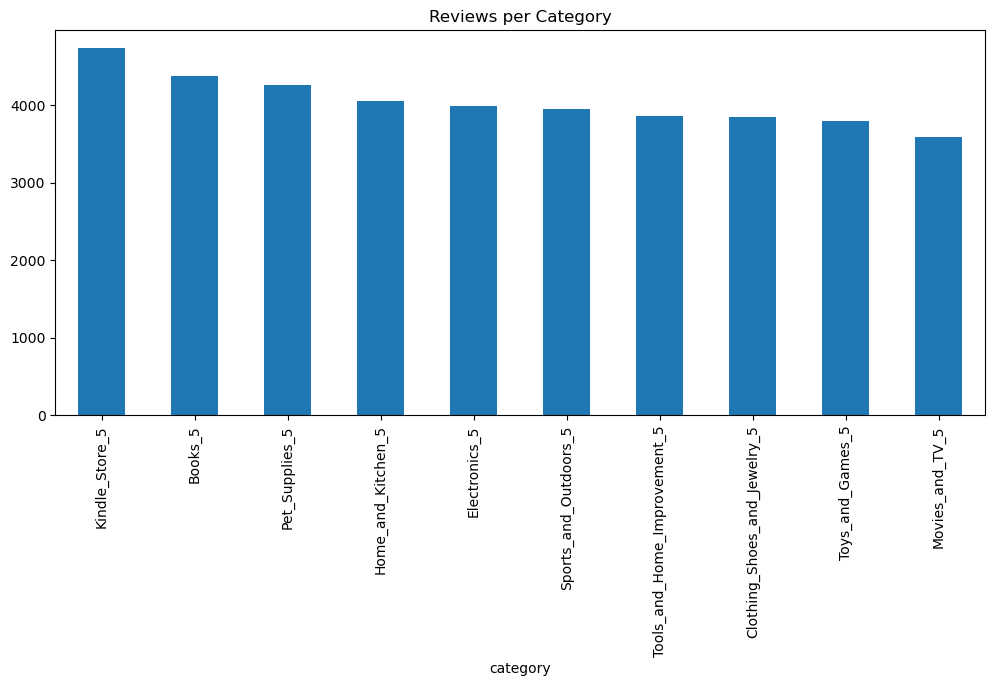

In [25]:
df['category'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title('Reviews per Category')
plt.show()

KEY INSIGHT: Which categories have most fake reviews?
This justifies engineering 'category_fake_rate' feature

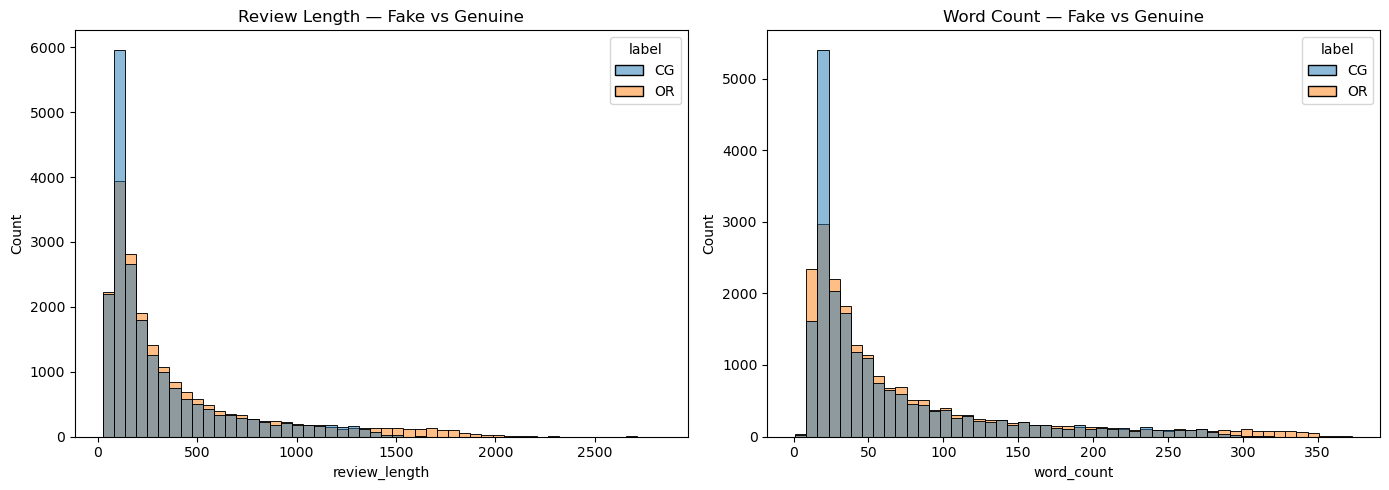

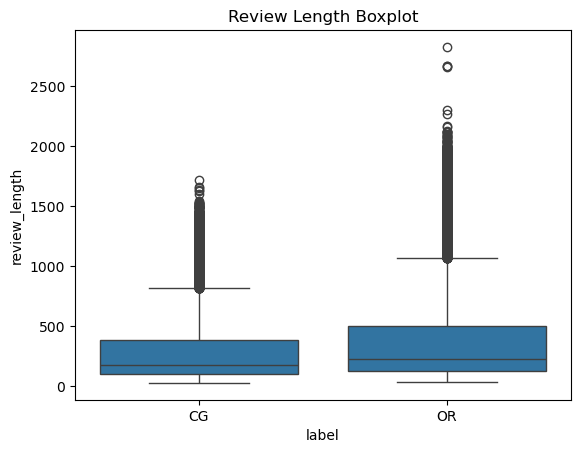

In [18]:
#  REVIEW TEXT LENGTH ANALYSIS 
df['review_length'] = df['text_'].apply(len)
df['word_count']    = df['text_'].apply(lambda x: len(x.split()))

# Length distribution fake vs genuine
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='review_length', hue='label', bins=50, ax=axes[0])
axes[0].set_title('Review Length — Fake vs Genuine')

sns.histplot(data=df, x='word_count', hue='label', bins=50, ax=axes[1])
axes[1].set_title('Word Count — Fake vs Genuine')

plt.tight_layout()
plt.show()

# Boxplot for cleaner comparison
sns.boxplot(x='label', y='review_length', data=df)
plt.title('Review Length Boxplot')
plt.show()

KEY INSIGHT: Are fake reviews shorter/longer?
This tells how important 'review_length' will be

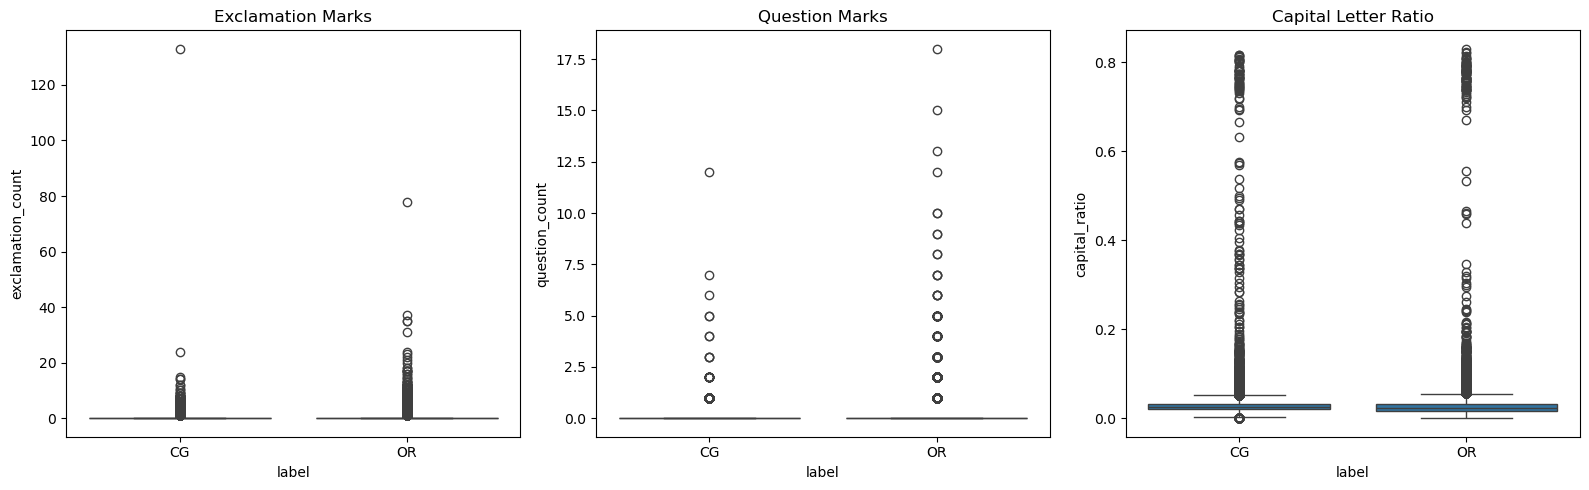

In [20]:
# SPECIAL CHARACTER ANALYSIS 
df['exclamation_count'] = df['text_'].apply(lambda x: x.count('!'))
df['question_count']    = df['text_'].apply(lambda x: x.count('?'))
df['capital_ratio']     = df['text_'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='label', y='exclamation_count', data=df, ax=axes[0])
axes[0].set_title('Exclamation Marks')

sns.boxplot(x='label', y='question_count', data=df, ax=axes[1])
axes[1].set_title('Question Marks')

sns.boxplot(x='label', y='capital_ratio', data=df, ax=axes[2])
axes[2].set_title('Capital Letter Ratio')

plt.tight_layout()
plt.show()

KEY INSIGHT: Fake reviews tend to have more exclamation marks and aggressive capitalization (hype writing pattern)

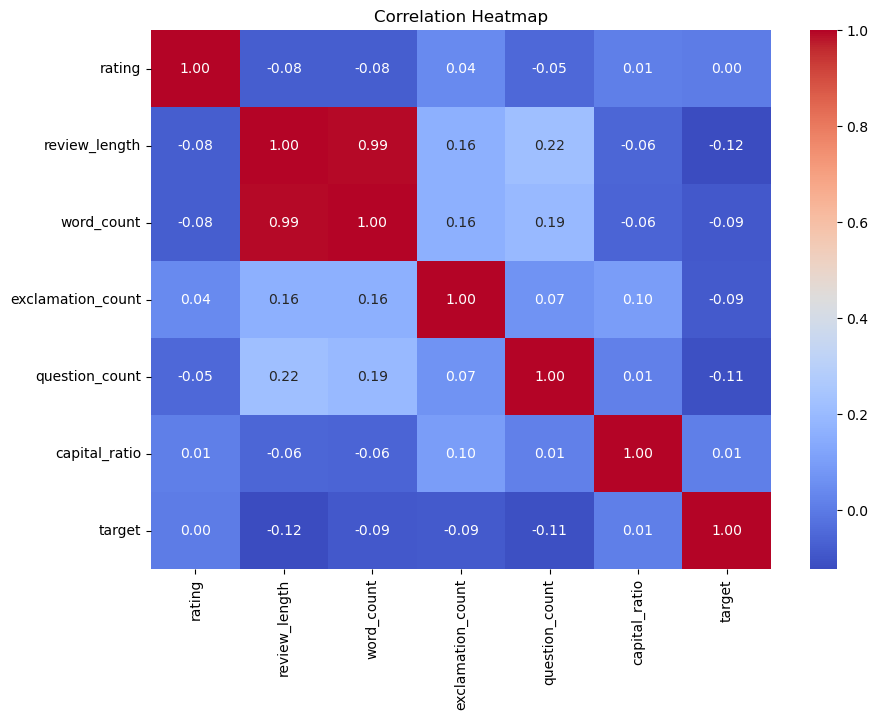

In [21]:
# CORRELATION HEATMAP 
df['target'] = df['label'].apply(lambda x: 1 if x == 'CG' else 0)

num_cols = ['rating', 'review_length', 'word_count',
            'exclamation_count', 'question_count', 'capital_ratio', 'target']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

KEY INSIGHT: Which raw features already correlate with target?
High correlation = strong feature, low = might not help

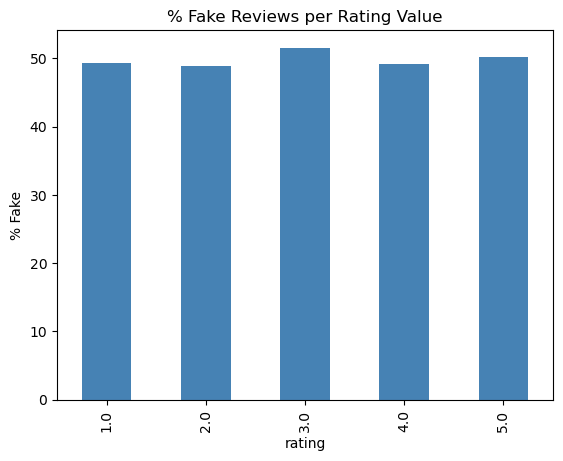

In [22]:
# RATING vs FAKE — DEEPER LOOK
rating_fake = df.groupby('rating')['target'].mean() * 100
rating_fake.plot(kind='bar', color='steelblue')
plt.title('% Fake Reviews per Rating Value')
plt.ylabel('% Fake')
plt.show()

KEY INSIGHT: If rating=5 has 70%+ fake rate →
extreme ratings are a strong signal → justifies 'is_extreme_rating' feature

In [23]:
# SUMMARY STATS TABLE
print(df.groupby('label')[['review_length', 'word_count',
      'exclamation_count', 'capital_ratio', 'rating']].mean().round(2))
# Clean printout of average values for fake vs genuine side by side

       review_length  word_count  exclamation_count  capital_ratio  rating
label                                                                     
CG            305.57       61.29               0.28           0.03    4.26
OR            396.97       73.64               0.52           0.03    4.25
